In [6]:
import json
import os

from SIMULATION_library.fch_setup import simulation
from SIMULATION_library.cell_sims_utils import generate_bench_script

In [7]:
# sims_number = 100
# Probably won't change

username                        = "crg17"
platform = "archer2"

# Particular experiment

folder_experiment_name = "rodero_healthy/h11/scenarios/8/"
num_beats_limit_cycle  = 500
num_beats              = 5
# bpm                    = 72
# bpm                    = 60
# bcl                    = int(60000/bpm) ### Change it also in the clinical_data json file

# HPC
# /work/e348/e348/crg17/rodero_healthy/h11/scenarios/5/states
# states_folder = f"/rds/general/user/{username}/home/{folder_experiment_name}/states" # put here the .sv files on the hpc
states_folder = f"/work/e348/e348/{username}/{folder_experiment_name}/states" # put here the .sv files on the hpc

# Local computer
base_folder_local   = f"/media/croderog/SeagateExpansionDrive/{folder_experiment_name}"
cell_sims_basefolder = f"{base_folder_local}/cell_sims"
torord_folder       = f"{base_folder_local}/SS/param"
courtemanche_folder = f"{base_folder_local}/SS/param"
data_folder          = f"{base_folder_local}/data"
json_folder = f"{base_folder_local}/json_files"

os.makedirs(cell_sims_basefolder, exist_ok=True)

# First we generate the simulation scripts. That will generate auxiliary cell simulation files

In [8]:

N = 100

# -------------------------------------------------------------------------
# write simulation scripts

cmd = f"python ../simulation_toolbox/write_simulation_scripts.py"
cmd += f" --datafolder {data_folder}"
cmd += f" --fields mechanics"
cmd += f" --platform {platform}"
cmd += f" --user {username}"
cmd += f" --paramfolder {base_folder_local}/json_files/"
cmd += f" --paramfolder_cell {base_folder_local}/SS/param/"
cmd += f" --slrmfolder {base_folder_local}/slrm/"
cmd += f" --HPC_statefolder {states_folder}"
cmd += f" --defaultfile {base_folder_local}/json_files/default.json"
cmd += f" --idx1 0"
cmd += f" --idx2 {N-1}"
cmd += f" --clinical_data {base_folder_local}/json_files/clinical_data.json"
cmd += f" --tags {base_folder_local}/json_files/tags.json"
cmd += f" --setup_file {base_folder_local}/json_files/settings_{platform}.json"
os.system(cmd)


Loading /media/croderog/SeagateExpansionDrive/rodero_healthy/h11/scenarios/8//json_files/settings_archer2.json...
Done.
generating json file...
mechanics
mechanics


mkdir: cannot create directory ‘/media/croderog/SeagateExpansionDrive/rodero_healthy/h11/scenarios/8//json_files/’: File exists


#######################################
    visualising setup for simulation   
#######################################
----------------------------
Four-chamber clock:
BCL : 1000.0
SA_t0 : -150.0
AV_delay : 150.0
LA_LV_delay : 150.0
RA_RV_delay : 150.0
ERP : 800.0
SA_RA_delay : 0.0
AA_delay : 0.0
VV_delay : 0.0
RA_AVa_delay : 0.0
----------------------------
----------------------------
Stimulus @ SAN:
stimID : 0
name : SAN
vtx_file : /work/e348/e348/crg17/meshes/rodero_healthy/h11//SAN
BCL : 1000.0
npls : 5
xtrg : 0
stim_type : 0
start : 0.0
strength : 60.0
duration : 2.0
xtrg_offset : 0.0
----------------------------
----------------------------
Stimulus @ fascicles_rv:
stimID : 1
name : fascicles_rv
vtx_file : /work/e348/e348/crg17/meshes/rodero_healthy/h11//fascicles_rv
BCL : 1000.0
npls : 5
xtrg : 1
stim_type : 0
start : 0.0
strength : 60.0
duration : 2.0
xtrg_offset : 0.0
----------------------------
----------------------------
Stimulus @ fascicles_lv:
stimID : 2
name : fascicl

0

# Ventricles: ToRORd_dynCl + LandHumanStress

In [9]:
sim_setup = simulation()
sim_setup.load(f"{json_folder}/settings_{platform}.json")

with open(f"{base_folder_local}/json_files/clinical_data.json","r") as f:
    clinical_data = json.load(f)


generate_bench_script(N=N,								# how many simulations to run (one per param.json)
					  BCL=clinical_data["general"]["BCL"],						    	# BCL
					  NBEATS=num_beats,							# NBEATS
					  basefolder=f"{base_folder_local}/SS/",				# basefolder containing the param folder
					  NPROC=23,							# number of CPUs to use for parallel runs
					  strain=0.0,								# strain
					  chamber="LV",		 						# chamber = LV, RV or atria
					  contraction_model=sim_setup.contraction_model, 		# contraction model
					  suffix="")

os.system(f"bash {base_folder_local}/SS/run_ToRORd_dynCl.sh")


Loading /media/croderog/SeagateExpansionDrive/rodero_healthy/h11/scenarios/8//json_files/settings_archer2.json...
Done.


0

# Atria: Converted COURTEMANCHE + LandHumanStress

In [10]:
sim_setup = simulation()
sim_setup.load(f"{json_folder}/settings_{platform}.json")


generate_bench_script(N=N,								# how many simulations to run (one per param.json)
					  BCL=clinical_data["general"]["BCL"],						    	# BCL
					  NBEATS=num_beats,							# NBEATS
					  basefolder=f"{base_folder_local}/SS/",				# basefolder containing the param folder
					  NPROC=23,							# number of CPUs to use for parallel runs
					  strain=0.0,								# strain
					  chamber="atria",		 						# chamber = LV, RV or atria
					  contraction_model=sim_setup.contraction_model, 		# contraction model
					  suffix="")

os.system(f"bash {base_folder_local}/SS/run_converted_COURTEMANCHE.sh")


Loading /media/croderog/SeagateExpansionDrive/rodero_healthy/h11/scenarios/8//json_files/settings_archer2.json...
Done.


0

# Quality check

In [23]:
from GSA_library import ionic_output, file_utils
import matplotlib.pyplot as plt
import numpy as np

In [24]:
ionic_output.bin_to_dat_folder(sim_foldername = "/media/croderog/SeagateExpansionDrive/HCM/10GH00962/scenarios/6/SS/ToRORd_dynCl/",
						  start_sample=0,
						  last_sample=99,
						  BCL=833,
						  Nbeats=5,
						  bin_files=["ToRORd_dynCl.Vm.bin","ToRORd_dynCl.Ca_i.bin","ToRORd_dynCl.Tension.bin"],
						  output_files=["ToRORd_dynCl.Vm.dat","Ca_i.dat","Tension.dat"],
						  cleanup=False)

In [25]:
def plot_Land_output(basefolder,
                     N,
                     figname=None,
                     isometric=False,
                     figsize=(10, 5),
                     mask=[],
                     default='',
                     color='#3489eb'):

    """
    Plot Land output calcium and tension.

    Args:
        - basefolder: containing all simulations, folder numbered from
                    0 to N-1
        - N: number of simulations to plot
        - figname: path to output figure. If None, the plot is shown
        - isometric: if True, no stretch is plotted
        - figsize: tuple, (width, height)
        - mask: boolean mask containing which simulations terminated successfully
                and which ones didn't
        - default: path to folder with Land output (Tension.dat for instance) 
                   that can be plotted against the simulations for comparison

    """

    if not isometric:
        ax = plt.figure(figsize=figsize, constrained_layout=True).subplots(1, 3)
    else:
        ax = plt.figure(figsize=figsize, constrained_layout=True).subplots(1, 2)

    plot_all = np.arange(N)
    if len(mask) > 0:
        plot_idx = plot_all[np.where(mask == 1)[0]]
    else:
        plot_idx = plot_all

    for i in plot_all:
        if not os.path.exists(basefolder+'/'+str(i)+'/Tension.dat'):
            raise Exception('Cannot find output file. The folder structure needs to be basefolder/i/Tension.dat and Ca_i.dat')

        T = file_utils.read_ionic_output(basefolder+'/'+str(i)+'/Tension.dat')
        Ca_i = file_utils.read_ionic_output(basefolder+'/'+str(i)+'/Ca_i.dat')
        t = np.arange(0, Ca_i.shape[0])

        if i in plot_idx:
            if np.max(np.abs(T)) < 500.0:
                # Plot the curve
                ax[0].plot(t, Ca_i, color=color)

                # Add a red star at the first point of the curve
                ax[0].plot(t[0], Ca_i[0], marker='*', markersize=8, color='red')

                ax[1].plot(t, T, color=color)
                ax[1].plot(t[0], T[0], marker='*', markersize=8, color='red')
        else:
            if np.max(np.abs(T)) < 500.0:
                ax[0].plot(t, Ca_i, color='black', zorder=0)
                ax[1].plot(t, T, color='black', zorder=0)

        ax[0].set_xlabel('Time [ms]')
        ax[1].set_xlabel('Time [ms]')

        ax[0].set_ylabel('Ca_i [um]')
        ax[1].set_ylabel('Tension [kPa]')

        # lambda_out = read_ionic_output(basefolder+'/'+str(i)+'/lambda.dat')
        if not isometric:
            lambda_out = file_utils.read_ionic_output(basefolder+'/'+str(i)+'/stretch.dat')
            if i in plot_idx:
                ax[2].plot(t, lambda_out, color=color)
                ax[2].plot(t[0], lambda_out[0], marker='*', markersize=8, color='red')
            else:
                ax[2].plot(t, lambda_out, color='black', zorder=0)

            ax[2].set_xlabel('Time [ms]')
            ax[2].set_ylabel('Lambda [-]')

        if default != '':
            T = file_utils.read_ionic_output(default+'/Tension.dat')
            Ca_i = file_utils.read_ionic_output(default+'/Ca_i.dat')

            ax[0].plot(t, Ca_i, '--',
                       color='black',
                       linewidth=2.0
                       )
            ax[1].plot(t, T, '--',
                       color='black',
                       linewidth=2.0
                       )

    if figname is None:
        plt.show()
    else:
        plt.savefig(figname, dpi=100)

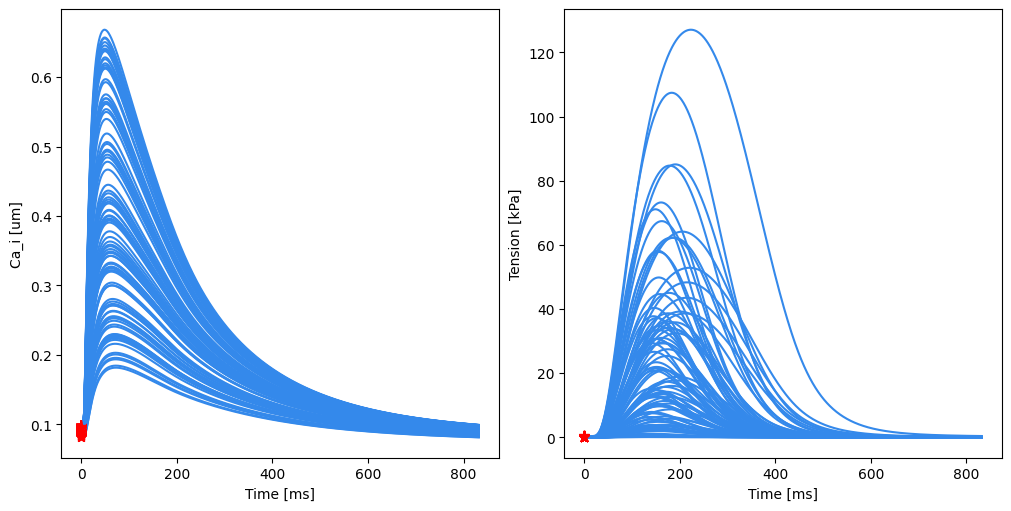

In [26]:
plot_Land_output(basefolder =  "/media/croderog/SeagateExpansionDrive/HCM/10GH00962/scenarios/6/SS/ToRORd_dynCl/",
                          N = 100,
                          isometric = True,
                          figname="/home/croderog/Desktop/delete/Land_output.png")